In [17]:
""" Libraries configuration for data preprocessing """

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder



In [18]:
data = r'D:\Phone addicted\Smartphone-Addiction-Warning-System-Rebuild-\data\Raw Data\teen_phone_addiction_dataset.csv'
df = pd.read_csv(data)
df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


## Data Understanding


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [20]:
df.isna().sum()

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

In [21]:
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [22]:
df.drop(columns=['ID','Name','Location'], inplace=True)

In [23]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['Gender', 'School_Grade', 'Phone_Usage_Purpose']


In [24]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print(numerical_cols)

['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']


In [25]:
columns_with_zero = df.columns[(df == 0).any()]
print(columns_with_zero)


Index(['Daily_Usage_Hours', 'Social_Interactions', 'Exercise_Hours',
       'Parental_Control', 'Screen_Time_Before_Bed', 'Time_on_Social_Media',
       'Time_on_Gaming', 'Time_on_Education', 'Weekend_Usage_Hours'],
      dtype='object')


In [31]:
df['Daily_Usage_Hours'] = df['Daily_Usage_Hours'].replace(0, df['Daily_Usage_Hours'].mean())
df['Social_Interactions'] = df['Social_Interactions'].replace(0, df['Social_Interactions'].mean())
df['Exercise_Hours'] = df['Exercise_Hours'].replace(0, df['Exercise_Hours'].mean())
df['Parental_Control'] = df['Parental_Control'].replace(0, df['Parental_Control'].mean())
df['Screen_Time_Before_Bed'] = df['Screen_Time_Before_Bed'].replace(0, df['Screen_Time_Before_Bed'].mean())
df['Time_on_Social_Media'] = df['Time_on_Social_Media'].replace(0, df['Time_on_Social_Media'].mean())
df['Time_on_Gaming'] = df['Time_on_Gaming'].replace(0, df['Time_on_Gaming'].mean())
df['Time_on_Education'] = df['Time_on_Education'].replace(0, df['Time_on_Education'].mean())
df['Weekend_Usage_Hours'] = df['Weekend_Usage_Hours'].replace(0, df['Weekend_Usage_Hours'].mean())


In [32]:
df.describe()

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,15.969667,5.062506,6.489767,74.947333,5.534367,1.167628,5.590000,5.460333,5.546333,0.757280,1.03660,83.093000,12.609333,2.516728,1.629493,1.101028,5.459667,6.017105,8.881900
std,1.989489,1.901582,1.490713,14.684156,2.727224,0.625598,2.890678,2.871557,2.860754,0.246348,0.46039,37.747044,4.611486,0.965659,0.836683,0.571896,2.864572,2.011779,1.609598
min,13.000000,0.100000,3.000000,50.000000,1.000000,0.100000,1.000000,1.000000,1.000000,0.507333,0.10000,20.000000,5.000000,0.100000,0.100000,0.100000,1.000000,0.100000,1.000000
25%,14.000000,3.800000,5.500000,62.000000,3.000000,0.800000,3.000000,3.000000,3.000000,0.507333,0.70000,51.000000,9.000000,1.800000,1.000000,0.700000,3.000000,4.700000,8.000000
50%,16.000000,5.000000,6.500000,75.000000,5.097667,1.040667,6.000000,5.000000,6.000000,1.000000,1.00000,82.000000,13.000000,2.500000,1.525267,1.016333,5.000000,6.000000,10.000000
75%,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.40000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.60000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


**Usage composition**

In [33]:
df['Tracked_Hours'] = df['Time_on_Social_Media'] + df['Time_on_Gaming'] + df['Time_on_Education']
df['Untracked_Hours'] = df['Daily_Usage_Hours'] - df['Tracked_Hours'] 
df['Leisure_Hours'] = df['Time_on_Social_Media'] + df['Time_on_Gaming']
df['Leisure_Ratio'] = df['Leisure_Hours'] / df['Daily_Usage_Hours']
df['Education_Ratio'] = df['Time_on_Education'] / df['Daily_Usage_Hours']
df['Social_vs_Gaming'] = df['Time_on_Social_Media'] - df['Time_on_Gaming']  

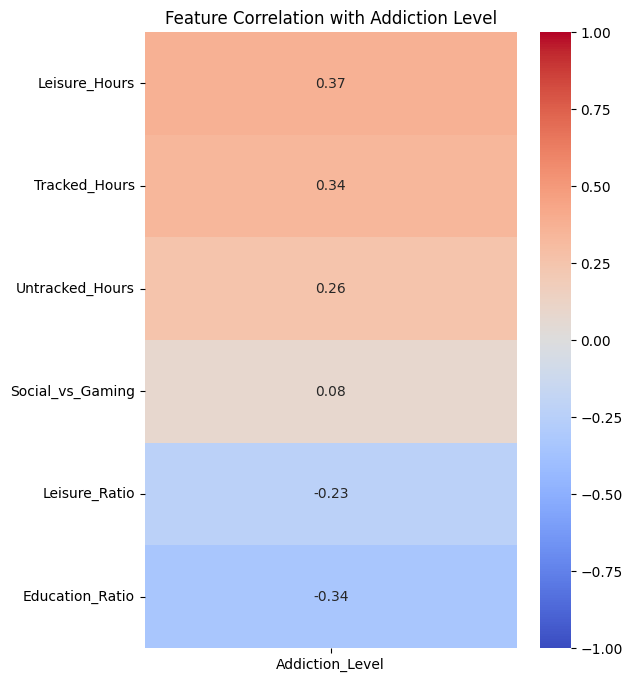

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the list of feature column names
features = [
    'Tracked_Hours',
    'Untracked_Hours',
    'Leisure_Hours',
    'Leisure_Ratio',
    'Education_Ratio',
    'Social_vs_Gaming',
]

# 2. Compute correlation of selected features specifically against 'Addiction_Level'
correlation = (
    df[features].apply(lambda x: x.corr(df['Addiction_Level'])).to_frame()
)
correlation.columns = ['Addiction_Level']

# 3. Plot single-column correlation heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlation.sort_values(by='Addiction_Level', ascending=False),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
)
plt.title('Feature Correlation with Addiction Level')
plt.show()
